In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import time
import numpy as np

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import models, layers, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
TRAIN_DATA_PATH = os.path.join("../affectnet_dataset/Train")
TEST_DATA_PATH = os.path.join("../affectnet_dataset/Test")
EPOCHS = 100
RANDOM_SEED = 40
BATCH_SIZE = 32
IMG_SIZE = (96,96)
SAVED_MODEL = "../saved_models/cnn_weighted_model.h5"
CLASSES = [d for d in os.listdir(TRAIN_DATA_PATH) if d != '.DS_Store']

In [3]:
# one hot encoding (categorical lbl mode)
train_dataset = image_dataset_from_directory(
    TRAIN_DATA_PATH,
    validation_split=0.2,
    subset="training",
    seed = RANDOM_SEED,
    image_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    label_mode = "categorical" 
)

val_dataset = image_dataset_from_directory(
    TRAIN_DATA_PATH,
    seed = RANDOM_SEED,
    image_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    label_mode = "categorical",
    validation_split=0.2,
    subset="validation"
)

test_dataset = image_dataset_from_directory(
    TEST_DATA_PATH,
    image_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    label_mode = "categorical" 
)

Found 16108 files belonging to 8 classes.
Using 12887 files for training.
Found 16108 files belonging to 8 classes.
Using 3221 files for validation.
Found 14518 files belonging to 8 classes.


In [4]:
# # CNN works better with 0-1 px values
# layer_normalization = Rescaling(1./255)

# train_dataset = train_dataset.map(lambda x, y: (layer_normalization(x), y))
# test_dataset = test_dataset.map(lambda x, y: (layer_normalization(x),y))

In [5]:
train_counts = {}

for cls in CLASSES:
    cls_folder = os.path.join(TRAIN_DATA_PATH, cls)
    train_counts[cls] = len(os.listdir(cls_folder))

print(train_counts)

{'anger': 1500, 'contempt': 1559, 'disgust': 1229, 'fear': 1512, 'happy': 2340, 'neutral': 2758, 'sad': 3091, 'surprise': 2119}


In [6]:
# Calculate class weights for imbalanced dataset
# Create label list manually from folder counts
labels = []

for idx, cls in enumerate(CLASSES):
    count = train_counts[cls]
    labels.extend([idx] * count)

labels = np.array(labels)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(zip(range(len(class_weights_array)), class_weights_array))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.3423333333333334), 1: np.float64(1.2915330339961513), 2: np.float64(1.6383238405207485), 3: np.float64(1.3316798941798942), 4: np.float64(0.8604700854700855), 5: np.float64(0.7300580130529369), 6: np.float64(0.6514073115496603), 7: np.float64(0.9502123643227938)}


In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [8]:
model = tf.keras.Sequential([
    layers.Input(shape=(75, 75, 3)),
    data_augmentation,
    # Rescaling layer to normalize pixel values to [0, 1] for CNN better performance
    # Rescaling is not needed if using a pretrained model that expects 0-255 input, but since we're building from scratch, it's beneficial to normalize the input.
    # Input normalization can help the model converge faster and improve performance.
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),

    layers.Flatten(),

    layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(8, activation='softmax')
])
model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(1e-4), metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 75, 75, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 75, 75, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 75, 75, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 75, 75, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 37, 37, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 37, 37, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 18, 18, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,469,480 (5.61 MB)

 Trainable params: 1,468,584 (5.60 MB)

 Non-trainable params: 896 (3.50 KB)

In [9]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
mc = ModelCheckpoint(SAVED_MODEL, monitor='val_accuracy', save_best_only=True)
csv_logger = CSVLogger('../logs/cnn_weighted_loss_training_log.csv')

In [10]:
start = time.time()
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=[es, mc, csv_logger]
)
end = time.time()

print("Training time: ", (end - start)/60)

Epoch 1/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.1484 - loss: 2.6366

403/403 ━━━━━━━━━━━━━━━━━━━━ 48s 115ms/step - accuracy: 0.1725 - loss: 2.5458 - val_accuracy: 0.2325 - val_loss: 2.0427
Epoch 2/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.2216 - loss: 2.2497

403/403 ━━━━━━━━━━━━━━━━━━━━ 47s 116ms/step - accuracy: 0.2302 - loss: 2.2102 - val_accuracy: 0.3313 - val_loss: 1.6343
Epoch 3/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.2670 - loss: 2.0426

403/403 ━━━━━━━━━━━━━━━━━━━━ 47s 117ms/step - accuracy: 0.2769 - loss: 2.0104 - val_accuracy: 0.3797 - val_loss: 1.5262
Epoch 4/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.2844 - loss: 1.9241

403/403 ━━━━━━━━━━━━━━━━━━━━ 47s 116ms/step - accuracy: 0.2934 - loss: 1.9121 - val_accuracy: 0.3887 - val_loss: 1.4763
Epoch 5/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.3112 - loss: 1.8188

...

403/403 ━━━━━━━━━━━━━━━━━━━━ 48s 118ms/step - accuracy: 0.5015 - loss: 1.3487 - val_accuracy: 0.5570 - val_loss: 1.1769
Epoch 27/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 47s 115ms/step - accuracy: 0.5161 - loss: 1.3278 - val_accuracy: 0.5349 - val_loss: 1.2067
Epoch 28/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 48s 120ms/step - accuracy: 0.5168 - loss: 1.3235 - val_accuracy: 0.5321 - val_loss: 1.2318
Epoch 29/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 46s 113ms/step - accuracy: 0.5196 - loss: 1.3067 - val_accuracy: 0.4983 - val_loss: 1.3239
Epoch 30/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 46s 113ms/step - accuracy: 0.5218 - loss: 1.3099 - val_accuracy: 0.5421 - val_loss: 1.2169
Epoch 31/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 48s 118ms/step - accuracy: 0.5296 - loss: 1.2960 - val_accuracy: 0.5545 - val_loss: 1.1722
Epoch 32/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 47s 117ms/step - accuracy: 0.5287 - loss: 1.2958 - val_accuracy: 0.5151 - val_loss: 1.2685
Epoch 33/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 46s 115ms/step - accuracy: 0.5320 - loss

403/403 ━━━━━━━━━━━━━━━━━━━━ 48s 119ms/step - accuracy: 0.5374 - loss: 1.2759 - val_accuracy: 0.5588 - val_loss: 1.1711
Epoch 36/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 48s 119ms/step - accuracy: 0.5384 - loss: 1.2660 - val_accuracy: 0.5321 - val_loss: 1.2256
Epoch 37/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 47s 117ms/step - accuracy: 0.5431 - loss: 1.2619 - val_accuracy: 0.5411 - val_loss: 1.2097
Epoch 38/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.5325 - loss: 1.2556

403/403 ━━━━━━━━━━━━━━━━━━━━ 49s 120ms/step - accuracy: 0.5406 - loss: 1.2595 - val_accuracy: 0.5697 - val_loss: 1.1528
Epoch 39/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.5438 - loss: 1.2569

403/403 ━━━━━━━━━━━━━━━━━━━━ 48s 118ms/step - accuracy: 0.5490 - loss: 1.2590 - val_accuracy: 0.5740 - val_loss: 1.1523
Epoch 40/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.5464 - loss: 1.2409

403/403 ━━━━━━━━━━━━━━━━━━━━ 48s 118ms/step - accuracy: 0.5478 - loss: 1.2399 - val_accuracy: 0.5914 - val_loss: 1.1184
Epoch 41/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 46s 115ms/step - accuracy: 0.5491 - loss: 1.2520 - val_accuracy: 0.5548 - val_loss: 1.1831
Epoch 42/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 47s 116ms/step - accuracy: 0.5503 - loss: 1.2324 - val_accuracy: 0.5806 - val_loss: 1.1275
Epoch 43/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 48s 119ms/step - accuracy: 0.5552 - loss: 1.2388 - val_accuracy: 0.5790 - val_loss: 1.1463
Epoch 44/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 46s 113ms/step - accuracy: 0.5554 - loss: 1.2367 - val_accuracy: 0.5744 - val_loss: 1.1466
Epoch 45/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 45s 112ms/step - accuracy: 0.5559 - loss: 1.2237 - val_accuracy: 0.5635 - val_loss: 1.1889
Epoch 46/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 45s 113ms/step - accuracy: 0.5599 - loss: 1.2303 - val_accuracy: 0.5657 - val_loss: 1.1551
Epoch 47/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 46s 114ms/step - accuracy: 0.5604 - loss

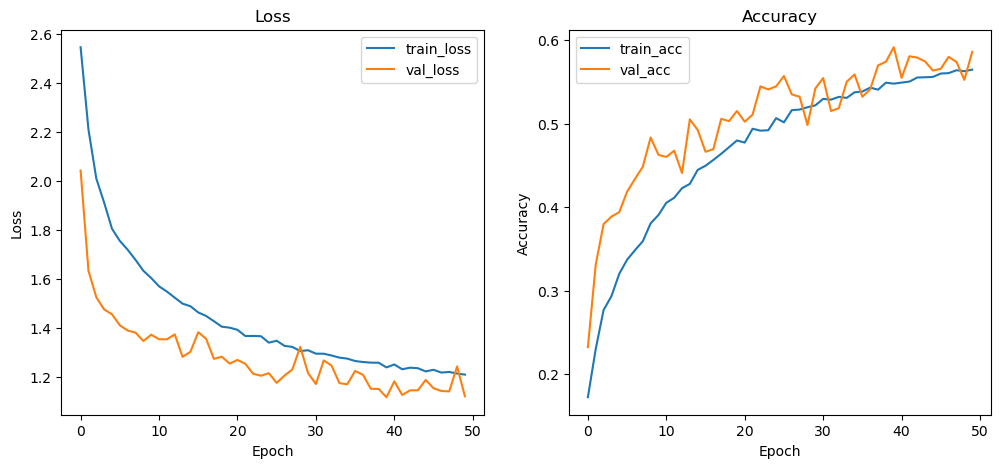

In [11]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [12]:
# os.stat("../saved_models/weighted_loss_model.h5").st_size

In [13]:
model = tf.keras.models.load_model(SAVED_MODEL)

In [14]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# # Predict probabilities
# yhat_probs = model.predict(test_dataset)  # shape (num_samples, 8)

# # Convert probabilities to predicted class indices
# yhat = np.argmax(yhat_probs, axis=1)

# # True class indices
# ytrue = np.argmax(CLASSES, axis=1)  # one-hot


# from sklearn.metrics import accuracy_score

# acc = accuracy_score(ytrue, yhat)
# print(f"Test Accuracy: {acc*100:.2f}%")

454/454 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.5958 - loss: 1.2067
Test Accuracy: 59.58%
